Célula 1 (Imports)

In [1]:
import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import pickle
import matplotlib.pyplot as plt

from src.tools import load_config, avaliar_modelo, registrar_metricas, previsao_venda_total, recursive_forecast_7days


In [ ]:
#🚩
config = load_config()
SPLIT_DATE = config['dates']['split_date']
EXCLUIR_COLUNA_MODELO = config['excluir_colunas_modelo']
ORDENACAO_BASE_BUSCA = config['ordenacao_base_busca']
DATA_FEATURES  ='../data/processed/dados_com_features.csv'
print(f'Colunas excluidas: {EXCLUIR_COLUNA_MODELO}')


Colunas excluidas: ['date', 'sales', 'id', 'sales_log', 'day_name', 'holiday_name', 'year']


In [4]:
# Configurações visuais
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

MODEL_PATH = '../models/xgb_model.json'
#🚩
# Tem que pegar o arquivo gerado no notebook anterio - .pkl
PICKLE_PATH = '../data/processed/dados_modelagem.pkl'


In [5]:
# >>>Abrir arquivo .pkl gerando anteriormente

# Carregue os dados já processados e divididos
with open(PICKLE_PATH, 'rb') as f:
    dados_modelagem = pickle.load(f)

X_train = dados_modelagem['X_train']
y_train = dados_modelagem['y_train']
X_val   = dados_modelagem['X_val']
y_val   = dados_modelagem['y_val']

In [6]:
X_train.columns

Index(['store', 'item', 'month', 'day', 'day_of_week', 'day_of_year',
       'is_weekend', 'is_payday', 'is_holiday', 'days_until_holiday',
       'month_sin', 'month_cos', 'day_of_week_sin', 'day_of_week_cos',
       'day_of_year_sin', 'day_of_year_cos', 'lag_1', 'lag_2', 'lag_3',
       'lag_7', 'lag_14', 'lag_21', 'lag_28', 'lag_91', 'rolling_mean_7',
       'rolling_std_7', 'rolling_mean_28', 'rolling_std_28', 'rolling_mean_91',
       'rolling_std_91', 'sales_diff_lag1', 'sales_diff_lag7'],
      dtype='object')

Célula 5 (Treinamento XGBoost)

In [7]:
X_train.columns

Index(['store', 'item', 'month', 'day', 'day_of_week', 'day_of_year',
       'is_weekend', 'is_payday', 'is_holiday', 'days_until_holiday',
       'month_sin', 'month_cos', 'day_of_week_sin', 'day_of_week_cos',
       'day_of_year_sin', 'day_of_year_cos', 'lag_1', 'lag_2', 'lag_3',
       'lag_7', 'lag_14', 'lag_21', 'lag_28', 'lag_91', 'rolling_mean_7',
       'rolling_std_7', 'rolling_mean_28', 'rolling_std_28', 'rolling_mean_91',
       'rolling_std_91', 'sales_diff_lag1', 'sales_diff_lag7'],
      dtype='object')

In [8]:
model = xgb.XGBRegressor(
    n_estimators=1000,      # Número máximo de árvores
    learning_rate=0.05,     # Taxa de aprendizado (menor é mais preciso, mas mais lento)
    max_depth=7,            # Profundidade da árvore (captura interações complexas)
    subsample=0.8,          # Evita overfitting usando apenas parte dos dados por árvore
    colsample_bytree=0.8,   # Evita overfitting usando apenas parte das features por árvore
    early_stopping_rounds=50, # Para se não melhorar em 50 rodadas
    n_jobs=-1,
    random_state=42
)

print("Iniciando treinamento...")
model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=100
)

print("Treinamento concluído.")

Iniciando treinamento...
[0]	validation_0-rmse:0.54727	validation_1-rmse:0.57651
[100]	validation_0-rmse:0.16286	validation_1-rmse:0.14319
[200]	validation_0-rmse:0.16060	validation_1-rmse:0.14192
[300]	validation_0-rmse:0.15914	validation_1-rmse:0.14139
[400]	validation_0-rmse:0.15793	validation_1-rmse:0.14109
[500]	validation_0-rmse:0.15684	validation_1-rmse:0.14090
[600]	validation_0-rmse:0.15584	validation_1-rmse:0.14076
[700]	validation_0-rmse:0.15488	validation_1-rmse:0.14067
[800]	validation_0-rmse:0.15402	validation_1-rmse:0.14062
[900]	validation_0-rmse:0.15317	validation_1-rmse:0.14056
[999]	validation_0-rmse:0.15236	validation_1-rmse:0.14054
Treinamento concluído.


In [9]:
print(X_train.columns)

Index(['store', 'item', 'month', 'day', 'day_of_week', 'day_of_year',
       'is_weekend', 'is_payday', 'is_holiday', 'days_until_holiday',
       'month_sin', 'month_cos', 'day_of_week_sin', 'day_of_week_cos',
       'day_of_year_sin', 'day_of_year_cos', 'lag_1', 'lag_2', 'lag_3',
       'lag_7', 'lag_14', 'lag_21', 'lag_28', 'lag_91', 'rolling_mean_7',
       'rolling_std_7', 'rolling_mean_28', 'rolling_std_28', 'rolling_mean_91',
       'rolling_std_91', 'sales_diff_lag1', 'sales_diff_lag7'],
      dtype='object')


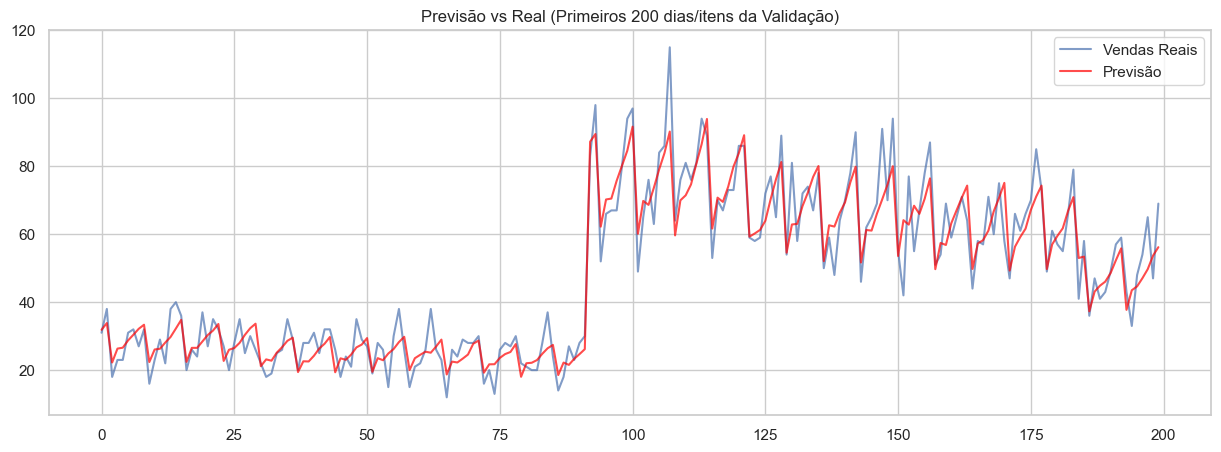

In [10]:
# # # Previsão
preds_log = model.predict(X_val)

# Inverter Log (np.expm1)
preds_real = np.expm1(preds_log)
y_val_real = np.expm1(y_val)
total_sales = np.sum(y_val_real)


# Plot Simples
plt.figure(figsize=(15, 5))
plt.plot(y_val_real.values[:200], label='Vendas Reais', alpha=0.7)
plt.plot(preds_real[:200], label='Previsão', alpha=0.7, color='red')
plt.title("Previsão vs Real (Primeiros 200 dias/itens da Validação)")
plt.legend()
plt.show()

In [11]:
#🚩
# >>>Avaliar modelo e registrar métricas para comparar no final 

# Avaliar modelo
metrics = avaliar_modelo(y_val, preds_log, nome_modelo="XGBoost")

# Registrar metrica
registrar_metricas(
    modelo_nome="XGBoost",
    mae=metrics['mae'],
    rmse=metrics['rmse'],
    wape=metrics['wape'],
    mape=metrics.get('mape', 0), # use get caso não tenha calculado mape antes
    r2=metrics['r2'], 
    notebook="03_training_and_evaluation.ipynb",
    etapa="treinamento"
)

rmse = metrics['rmse']

--- Performance: XGBoost ---
MAE:  6.53 (Erro médio em unidades)
RMSE: 8.49 (Penaliza erros grandes)
WAPE: 9.59% (Erro percentual ponderado)
MAPE: 11.21% (Erro médio absoluto)
R²:   0.9386 (Aderência/Variância explicada)
------------------------------
✅ Métricas registradas com sucesso em: c:\Users\Sergio\Desktop\_ESTUDO\_portifolio_full\retail-demand-forecasting\data/metrics\metrics_history.csv


Célula 7 (Importância das Features)

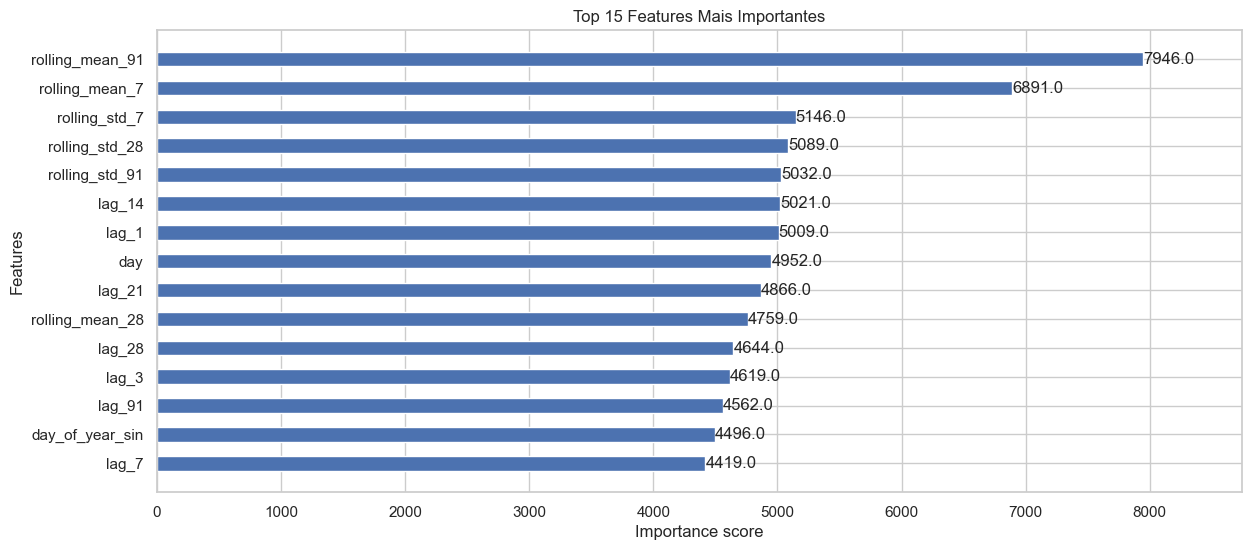

In [12]:
xgb.plot_importance(model, max_num_features=15, height=0.5)
plt.title("Top 15 Features Mais Importantes")
plt.show()

Célula 8 (Seleção de Amostra)

In [ ]:
# pegar a data para fazer o recursivo

# 1. Carregar o dataframe COMPLETO que tem a coluna 'date'
# Ajuste o caminho se necessário, baseando-me na sua imagem:
df_com_datas = pd.read_csv(DATA_FEATURES)

# 2. Converter a coluna 'date' para datetime (o CSV perde essa formatação ao salvar)
df_com_datas['date'] = pd.to_datetime(df_com_datas['date'])

# 3. Filtrar apenas o período relevante se o arquivo for muito grande (opcional)
# Mas para garantir, vamos usar ele todo.

print("Arquivo carregado. Colunas disponíveis:", df_com_datas.columns)

Arquivo carregado. Colunas disponíveis: Index(['date', 'store', 'item', 'sales', 'sales_log', 'year', 'month', 'day',
       'day_of_week', 'day_name', 'day_of_year', 'is_weekend', 'is_payday',
       'holiday_name', 'is_holiday', 'days_until_holiday', 'month_sin',
       'month_cos', 'day_of_week_sin', 'day_of_week_cos', 'day_of_year_sin',
       'day_of_year_cos', 'lag_1', 'lag_2', 'lag_3', 'lag_7', 'lag_14',
       'lag_21', 'lag_28', 'lag_91', 'rolling_mean_7', 'rolling_std_7',
       'rolling_mean_28', 'rolling_std_28', 'rolling_mean_91',
       'rolling_std_91', 'sales_diff_lag1', 'sales_diff_lag7'],
      dtype='object')


In [14]:
# Loja e Item aleatórios do conjunto de validação para simular
sample_store = 1
sample_item = 1
current_stock=10

# Dados mais recentes disponíveis no treino (data de corte)
# last_date_train = df_com_datas['date'].max()

last_date_train = pd.to_datetime("2017-08-01")   # data existe no train.csv -para validar -auditoria
# last_date_train = pd.to_datetime("30/09/2017")

#somente na base original tem data, por isso inclui a data deseja que existe na base original

print(f"Simulando previsão de 7 dias para \nLoja {sample_store}, \nItem {sample_item} \na partir de {last_date_train} \ncom estoque {current_stock}")

Simulando previsão de 7 dias para 
Loja 1, 
Item 1 
a partir de 2017-08-01 00:00:00 
com estoque 10


Célula 9 (Previsão Recursiva)

In [15]:
# >>>Executar simulação

features = X_train.columns.to_list()

forecast_7d = recursive_forecast_7days(model, df_com_datas, sample_store, sample_item, last_date_train, features)

print(f"Previsão dia a dia (7 dias): {np.round(forecast_7d, 2)}")

Previsão dia a dia (7 dias): [22.77 22.69 25.1  26.79 28.37 17.82 20.52]


Célula 10 (Decisão de Compra)

In [16]:
# >>>previsão de compra

# previsao_venda_total(forecast_7d, rmse, sample_store=1, sample_item=1, lead_time=7, z_score=1.65, current_stock=10)
previsao_venda_total(forecast_7d, rmse, sample_store, sample_item, current_stock)


--- Relatório de Reposição (Loja 1 - Item 1) ---
1. Previsão de Vendas (7 dias): 164.06 unidades
2. Estoque de Segurança (95%):  44.29 unidades
3. Estoque Atual na Loja:       10 unidades
--------------------------------------------------
✅ SUGESTÃO DE COMPRA:          198 unidades
--------------------------------------------------
Nota: Se comprar menos que isso, risco de Stockout > 5%.
      Se comprar muito mais, risco de custo de estocagem (Overstock).


In [21]:
# CÁLCULO DA MELHORIA (LIFT) PARA O PORTFÓLIO

wape_baseline = 13.73  # wape vem do notebook 03_naive... (baseline)

# 2. Insira aqui o WMAE do seu modelo XGBoost
# Esse valor deve estar na variável final de avaliação deste notebook
# Se a variável tiver outro nome (ex: 'wmae_xgb'), ajuste abaixo
wape_modelo = metrics['wape']

# 3. Cálculo da porcentagem de melhoria
melhoria = (wape_baseline - wape_modelo) / wape_baseline

print(f"--- RESULTADO PARA O PORTFÓLIO ---")
print(f"Erro Baseline (Média Móvel): {wape_baseline}")
print(f"Erro Modelo (XGBoost):       {wape_modelo}")
print(f"Melhoria Obtida (XX%):       {melhoria:.2%}")

--- RESULTADO PARA O PORTFÓLIO ---
Erro Baseline (Média Móvel): 13.73
Erro Modelo (XGBoost):       9.591676377231218
Melhoria Obtida (XX%):       30.14%


In [ ]:
#audidoria: gráfico para validar se esta certo ou um vazamento de informação
# como eu sei os valores vendidos em agosto. Quero verificar como o modelo se comporta 



# Criar um DataFrame para comparar
datas_previsao = pd.date_range(start=last_date_train + pd.Timedelta(days=1), periods=7)

comparison_df = pd.DataFrame({
    'Date': datas_previsao,
    'Forecast_Recursivo': forecast_7d
})

# Buscar os valores REAIS na base original para essas datas
# Garante que está pegando a mesma loja e item
actual_sales = df_com_datas[
    (df_com_datas['store'] == sample_store) & 
    (df_com_datas['item'] == sample_item) & 
    (df_com_datas['date'].isin(datas_previsao))
].sort_values('date')['sales'].values

# Adiciona ao DF (se o tamanho bater)
if len(actual_sales) == 7:
    comparison_df['Vendas_Reais'] = actual_sales
    
    # 3. Plotar
    plt.figure(figsize=(12, 6))
    plt.plot(comparison_df['Date'], comparison_df['Vendas_Reais'], label='Vendas Reais (Gabarito)', marker='o', linewidth=2)
    plt.plot(comparison_df['Date'], comparison_df['Forecast_Recursivo'], label='Previsão Recursiva (Modelo)', marker='x', linestyle='--', color='red', linewidth=2)
    
    plt.title(f"Prova Real: Previsão Recursiva vs Realidade (Loja {sample_store}, Item {sample_item})")
    plt.ylabel("Vendas")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    
    # Mostrar números
    print(comparison_df)
    
    # Calcular erro simples para esses 7 dias
    erro_total = sum(comparison_df['Forecast_Recursivo']) - sum(comparison_df['Vendas_Reais'])
    print(f"\nDiferença Total (7 dias): {erro_total:.2f} unidades")
else:
    print(f"Erro: Encontramos {len(actual_sales)} dias reais, mas esperávamos 7. Verifique se há dados faltantes nessa data.")


Célula 11 (Salvar Modelo)

In [ ]:
# Salvar modelo para usar no App/API
model.save_model(MODEL_PATH)
print(f"Modelo salvo em: {MODEL_PATH}")